<h2>Задание 1</h2>
<b>Реализовать поиск в глубину и поиск в ширину </b> (с выводом порядка обхода).


Найти компоненты связности графа из файла Graph1.csv (каждая строка 
содержит ребро)

In [100]:
import pandas as pd

link = "C:/Users/User/Desktop/Graph1.csv"
df = pd.read_csv(link, names=['from', 'to'] )
df.head()

,from,to
0,18,3
1,15,12
2,3,11
3,16,7
4,3,10


<h3>Записываем ребра и вершины из csv в удобный формат</h3>

In [103]:
edges = [[df['from'].tolist()[i], df['to'].tolist()[i]] for i in range(len(df))]
nodes = set()

for i in range(len(edges)):
    nodes.add(edges[i][0])
    nodes.add(edges[i][1])
nodes = list(nodes)

<h3>Изобразим граф</h3>

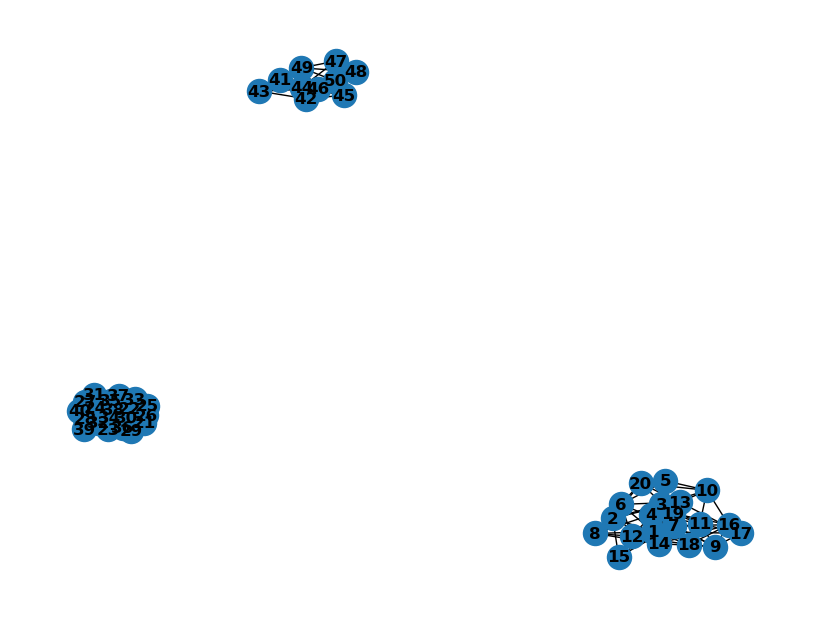

In [106]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_nodes_from(nodes)
G.add_edges_from(edges)

plt.figure(figsize = (8,6))
nx.draw(G, with_labels = True, font_weight = 'bold')
plt.show()

<h3>Запишем граф в виде списка смежных вершин</h3>

In [109]:
graph = {}

for node in edges:
    if node[0] not in graph :
        graph[node[0]] = []
        
    graph[node[0]].append(node[1])
    
    if node[1] not in graph:
        graph[node[1]] = []
    
    graph[node[1]].append(node[0])
graph

{18: [3, 1, 11, 12, 12, 1, 16, 7, 9, 12],
 3: [18, 11, 10, 11, 5, 13, 2, 5, 12, 7],
 15: [12, 2, 1, 2, 7],
 12: [15, 8, 14, 11, 19, 6, 3, 18, 18, 11, 11, 18],
 11: [3, 3, 12, 4, 9, 18, 1, 12, 19, 10, 17, 12, 19],
 16: [7, 14, 17, 10, 9, 10, 19, 18],
 7: [16, 5, 6, 6, 13, 9, 14, 3, 6, 18, 15],
 10: [3, 4, 5, 16, 16, 20, 11],
 4: [10, 5, 8, 19, 14, 1, 11, 9, 13],
 8: [12, 1, 14, 4, 6, 6, 14, 2, 1],
 1: [8, 18, 6, 17, 15, 4, 11, 19, 18, 14, 13, 8, 2],
 5: [7, 4, 10, 6, 3, 3],
 14: [16, 12, 8, 2, 9, 7, 9, 4, 8, 19, 9, 1, 19],
 20: [19, 2, 13, 6, 10, 13],
 19: [20, 4, 12, 16, 14, 1, 11, 14, 13, 11],
 6: [1, 7, 7, 5, 2, 8, 8, 12, 20, 13, 7],
 2: [15, 14, 20, 6, 3, 15, 13, 8, 1],
 17: [1, 16, 13, 9, 11],
 9: [14, 7, 14, 4, 11, 16, 14, 17, 18],
 13: [7, 3, 2, 17, 20, 6, 1, 20, 4, 19],
 28: [30,
  35,
  23,
  23,
  37,
  30,
  24,
  34,
  39,
  36,
  21,
  40,
  36,
  23,
  33,
  27,
  24,
  31,
  24,
  27,
  25,
  23,
  21,
  22,
  38,
  30,
  34,
  29,
  25,
  32,
  22,
  38,
  33,
  31,
  39

<h3>Реализация алгоритма поиска в глубину</h3>

In [112]:
import sys
sys.setrecursionlimit(2000)

def dfs_recursive(graph, start, visited, path):
    if visited is None:
        visited = set()
    visited.add(start)
    path.append(start)
    for neighbor in graph[start]:
        if neighbor not in visited:
            dfs_recursive(graph, neighbor, visited, path)

<h5>Проверим алгоритм:</h5>

In [115]:
visited = set()
path = []

dfs_recursive(graph, 1, visited,path)

print('Работа алгоритма поиска в глубину от вершины 1')
path

Работа алгоритма поиска в глубину от вершины 1


[1, 8, 12, 15, 2, 14, 16, 7, 5, 4, 10, 3, 18, 11, 9, 17, 13, 20, 19, 6]

<h3>Реализация алгоритма поиска в глубину</h3>

In [118]:
import collections

def bfs(graph, root,path):

    visited, queue = set(), collections.deque([root])
    visited.add(root)
    while queue:
        vertex = queue.popleft()
        path.append(vertex)

        for neighbour in graph[vertex]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)


<h5>Проверим алгоритм:</h5>

In [121]:
path2 = []

bfs(graph,1, path2)

print('Работа алгоритма поиска в глубину от вершины 1')
path2

Работа алгоритма поиска в глубину от вершины 1


[1, 8, 18, 6, 17, 15, 4, 11, 19, 14, 13, 2, 12, 3, 16, 7, 9, 5, 20, 10]

<h5>
    Если алгоритмы правильно работают то результат для первого алгоритма совпадет с результатом второго
</h5>

In [124]:
if sorted(path) == sorted(path2):
    print('Алгоритмы работают')
else:
    print('Нет, алгоритмы не работают')

Алгоритмы работают


<h4>Теперь найдем все компоненты связности (с помощью алгоритма в ширину)</h4>
Пройтись по всем вершинам графа, последовательно запуская BFS (обход в ширину) для каждой ещё не посещённой вершины. Каждый запуск BFS будет находить все вершины, достижимые из текущей, образуя одну компоненту связности. Собрать все такие группы вершин в список — это и будут компоненты связности графа. 

Итог: BFS превращает граф в набор отдельных «островков» связных вершин.

In [127]:
result = []
vis = set()
for i in range(len(nodes)):
    if nodes[i] not in vis:
        path = []
        bfs(graph, nodes[i],path)
        for j in path:
            vis.add(j)
        result.append(path)

<h3>Answer:</h3>

In [130]:

print("""Количество компонент связности: {}
Первая комонента связности состоит из вершин: {}
Первая комонента связности состоит из вершин: {}
Первая комонента связности состоит из вершин: {}
""".format(len(result), result[0], result[1], result[2]))
      

Количество компонент связности: 3
Первая комонента связности состоит из вершин: [1, 8, 18, 6, 17, 15, 4, 11, 19, 14, 13, 2, 12, 3, 16, 7, 9, 5, 20, 10]
Первая комонента связности состоит из вершин: [21, 37, 26, 34, 23, 25, 24, 32, 33, 28, 30, 38, 36, 22, 31, 35, 29, 39, 27, 40]
Первая комонента связности состоит из вершин: [41, 46, 43, 50, 45, 42, 49, 47, 44, 48]

